# Taiwan Stock Market AI Trading Model
## Strategy Analysis & Performance Report

This notebook covers the full evaluation pipeline — from model classification metrics
through realistic backtesting to advanced multi-horizon signal analysis.

Run cells **top to bottom** to reproduce all results.

| Section | Content |
|---------|----------|
| 1 | Setup & environment check |
| 2 | Strategy architecture |
| 3 | Classification performance (ROC-AUC, PR-AUC) |
| 4 | Precision-Recall curves |
| 5 | Confusion matrix |
| 6 | Calibration: prob → return |
| 7 | Backtest simulation |
| 8 | Threshold sensitivity |
| 9 | **Multi-horizon signal interaction analysis** |
| 10 | **Horizon slope (prob momentum) analysis** |
| 11 | **Multi-strategy backtest comparison** |
| 12 | Live market scan |

---
## 1. Setup

In [1]:
import os, sys, warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import sqlite3
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from IPython.display import display

plt.rcParams.update({'figure.figsize': (12, 5), 'figure.dpi': 100})
sns.set_theme(style='whitegrid', palette='muted')

# Auto-detect project root
_root = os.getcwd()
for _ in range(6):
    if os.path.isdir(os.path.join(_root, 'core')) and os.path.isdir(os.path.join(_root, 'models')):
        break
    _root = os.path.dirname(_root)

PROJECT_ROOT = _root
CORE_DIR     = os.path.join(PROJECT_ROOT, 'core')
RESEARCH_DIR = os.path.join(PROJECT_ROOT, 'research')
MODELS_DIR   = os.path.join(PROJECT_ROOT, 'models')
DB_PATH      = os.path.join(PROJECT_ROOT, 'data', 'twstock.db')

for _p in [CORE_DIR, RESEARCH_DIR]:
    if _p not in sys.path:
        sys.path.insert(0, _p)

# print(f'Project root : {PROJECT_ROOT}')
# print(f'DB           : {DB_PATH}  [exists: {os.path.exists(DB_PATH)}]')

In [2]:
from Feature_Engineering_V2 import prepare_training_data_v2
import Performance_Report_V2 as PR2
import Backtest_V2 as BT2

PR2.DB_PATH     = DB_PATH
PR2.MODELS_DIR  = MODELS_DIR
PR2.OUTPUT_PATH = os.path.join(PROJECT_ROOT, 'market_scan_results.csv')
BT2.DB_PATH     = DB_PATH
BT2.MODELS_DIR  = MODELS_DIR
BT2.BASE_DIR    = PROJECT_ROOT

print('All imports OK.')

All imports OK.


In [3]:
HORIZONS = [1, 2, 3, 7, 14]

print('=== Model Files ===')
available_models = {}
for d in HORIZONS:
    path   = os.path.join(MODELS_DIR, f'xgb_universal_{d}d.pkl')
    exists = os.path.exists(path)
    size   = os.path.getsize(path) / 1e6 if exists else 0
    available_models[d] = {'exists': exists, 'path': path, 'size_mb': size}
    print(f'  [{"OK" if exists else "MISSING":>7}] xgb_universal_{d}d.pkl  ({size:.1f} MB)')

print('\n=== Database ===')
conn     = sqlite3.connect(DB_PATH)
n_rows   = pd.read_sql('SELECT COUNT(*) AS n FROM tw_stock_prices', conn).iloc[0]['n']
n_stocks = pd.read_sql('SELECT COUNT(DISTINCT Stock_ID) AS n FROM tw_stock_prices', conn).iloc[0]['n']
dates    = pd.read_sql('SELECT MIN(Date) AS mn, MAX(Date) AS mx FROM tw_stock_prices', conn).iloc[0]
conn.close()
print(f'  Stocks : {n_stocks:,}')
print(f'  Rows   : {n_rows:,}')
print(f'  Range  : {dates["mn"]}  ->  {dates["mx"]}')

=== Model Files ===
  [     OK] xgb_universal_1d.pkl  (1.9 MB)
  [     OK] xgb_universal_2d.pkl  (1.9 MB)
  [     OK] xgb_universal_3d.pkl  (1.9 MB)
  [     OK] xgb_universal_7d.pkl  (1.9 MB)
  [     OK] xgb_universal_14d.pkl  (1.9 MB)

=== Database ===
  Stocks : 1,966
  Rows   : 2,833,826
  Range  : 2020-01-02 00:00:00  ->  2026-05-28 00:00:00


---
## 2. Strategy Architecture Overview

### Full Pipeline

```
TWSE OHLCV  ->  Feature Engineering  ->  XGBoost Classifier  ->  Prob(Up)  ->  Trade Signal
```

### Feature Engineering

| Category | Features | Description |
|----------|----------|-------------|
| Price changes | Open_Gap, High_Chg, Low_Chg, Close_Chg | Normalized intraday moves vs prior close |
| Moving avg bias | Bias_5/10/20/60 | Close / SMA(N) − 1 |
| Volatility | NATR, Daily_Range_Pct | Normalized ATR |
| Momentum | RSI, MACD_Hist_Norm, Close_Loc | Relative strength, MACD signal |
| Volume | Vol_Chg | Volume change rate |
| External | SOX, S&P500, TSM ADR, TWII | Global co-movement (Lag 1-5) |
| Lags | *_Lag_1..5 | 5-day history of all key features |

### Why Five Separate Models?

Each prediction horizon captures a fundamentally different signal:

| Model | Horizon | Primary signal type |
|-------|---------|---------------------|
| 1d | Next close | Inertia, overnight gap, momentum |
| 2d | 2 days | Short earnings/event follow-through |
| 3d | 3 days | Short-term trend continuation |
| 7d | 1 week | Medium swing, sector rotation |
| 14d | 2 weeks | Macro positioning, fund flow |

Using them **together** (Section 9-11) is more powerful than any single model alone.

### Trade Execution Logic

```
Prob(Up) > 0.70  ->  Enter full position at today's close
Prob(Up) < 0.35  ->  Exit full position at today's close
```

The 35%-gap between entry and exit thresholds creates a **dead zone** that prevents
excessive churning when the model oscillates near the boundary.

### Cost Model

| Item | Rate | Notes |
|------|------|-------|
| Brokerage fee | 0.1425% × 2 | Buy + sell |
| Securities tax | 0.3% | Sell only |
| Slippage | 0.1% × 2 | Bid-ask + market impact |
| **Round-trip total** | **~0.685%** | Applied in every backtest |

A round-trip cost of ~0.685% means each trade needs to gain at least **0.7%** just to break even.
This naturally limits overtrading and filters out marginal signals.

In [4]:
params = {
    'Initial Capital':  f'TWD {BT2.INITIAL_CAPITAL:,.0f}',
    'Buy Threshold':    f'Prob > {BT2.BUY_THRESHOLD:.0%}',
    'Sell Threshold':   f'Prob < {BT2.SELL_THRESHOLD:.0%}',
    'Fee (each side)':  f'{BT2.FEE:.4%}',
    'Tax (sell only)':  f'{BT2.TAX:.2%}',
    'Slippage (each)':  f'{BT2.SLIPPAGE:.2%}',
    'Round-trip cost':  f'{(BT2.FEE + BT2.SLIPPAGE) * 2 + BT2.TAX:.4%}',
    'Risk-free rate':   f'{BT2.RISK_FREE_ANNUAL:.1%} / yr',
    'Eval start date':  str(BT2.EVAL_START_DATE),
    'Random seed':      str(BT2.RANDOM_SEED),
}
print('=== Trading Strategy Parameters ===')
for k, v in params.items():
    print(f'  {k:<22}: {v}')

=== Trading Strategy Parameters ===
  Initial Capital       : TWD 1,000,000
  Buy Threshold         : Prob > 70%
  Sell Threshold        : Prob < 40%
  Fee (each side)       : 0.1425%
  Tax (sell only)       : 0.30%
  Slippage (each)       : 0.10%
  Round-trip cost       : 0.7850%
  Risk-free rate        : 2.0% / yr
  Eval start date       : 2025-01-01
  Random seed           : 33


---
## 3. Classification Performance Evaluation

We evaluate on **8 out-of-sample test stocks** (`2344, 2834, 1402, 2618, 3045, 2912, 2207, 9910`)
that were never seen during training.

**Key metrics and their meaning:**

- **ROC-AUC**: Probability that the model ranks a random positive (Up) bar above a random
  negative (Down) bar. AUC = 0.5 is random; AUC = 0.6 on real market data is considered useful.
  Note: ROC-AUC is insensitive to class imbalance and can look artificially high.

- **PR-AUC (Avg Precision)**: More stringent than ROC — it heavily penalizes false positives.
  For trading, we care more about *precision* (when we say Buy, are we right?) than recall
  (did we catch every up move?). A PR-AUC of 0.55+ on filtered stock data is meaningful.

- **Best Threshold**: The probability cutoff that maximizes F1 on the test set.
  This is the **model's statistical optimum**, but the *trading* threshold (0.70) is set higher
  to favor precision over recall — we'd rather miss an opportunity than take a bad trade.

- **Per-stock AUC**: Variation across stocks tells us how generalizable the model is.
  High variance (some stocks AUC 0.70, others 0.50) suggests the model works better on
  certain market caps or sectors.

In [5]:
horizon_results = PR2.section1_model_evaluation()


════════════════════════════════════════════════════════════
SECTION 1 — Model Performance (Unseen Test Stocks)
════════════════════════════════════════════════════════════

  [1d model]  n=6,162
    ROC-AUC:     0.7397
    PR-AUC:      0.7341
    Accuracy:    0.6665
    Best Threshold (max F1=0.7104): 0.3826  [Prec=0.5899, Rec=0.8928]

    Per-stock AUC:
      2344: AUC=0.754  Acc=0.681  (n=997)
      2834: AUC=0.817  Acc=0.722  (n=609)
      1402: AUC=0.750  Acc=0.665  (n=725)
      2618: AUC=0.697  Acc=0.629  (n=895)
      3045: AUC=0.703  Acc=0.648  (n=483)
      2912: AUC=0.666  Acc=0.610  (n=700)
      2207: AUC=0.804  Acc=0.721  (n=831)
      9910: AUC=0.715  Acc=0.655  (n=922)

  [2d model]  n=6,194
    ROC-AUC:     0.7260
    PR-AUC:      0.7258
    Accuracy:    0.6568
    Best Threshold (max F1=0.7129): 0.3660  [Prec=0.5911, Rec=0.8980]

    Per-stock AUC:
      2344: AUC=0.764  Acc=0.681  (n=992)
      2834: AUC=0.773  Acc=0.681  (n=661)
      1402: AUC=0.739  Acc=0.681  (n

In [6]:
if horizon_results:
    PR2.print_summary_table(horizon_results)

    rows = []
    for days, res in horizon_results.items():
        rows.append({'Horizon': f'{days}d', 'ROC-AUC': round(res['auc'], 4),
                     'PR-AUC': round(res['ap'], 4), 'Accuracy': round(res['acc'], 4),
                     'Best Thr': round(res['threshold'], 4), 'F1': round(res['f1'], 4),
                     'Precision': round(res['precision'], 4), 'Recall': round(res['recall'], 4)})
    display(pd.DataFrame(rows).set_index('Horizon'))


════════════════════════════════════════════════════════════
SUMMARY — All Horizons
════════════════════════════════════════════════════════════
   Horizon   ROC-AUC   PR-AUC   Accuracy   Best Thr       F1
  ──────────────────────────────────────────────────────────
        1d    0.7397   0.7341     0.6665     0.3826   0.7104
        2d    0.7260   0.7258     0.6568     0.3660   0.7129
        3d    0.7142   0.7161     0.6493     0.3871   0.7058
        7d    0.7002   0.7043     0.6420     0.3591   0.7038
       14d    0.6854   0.6946     0.6329     0.3392   0.6782


,ROC-AUC,PR-AUC,Accuracy,Best Thr,F1,Precision,Recall
Horizon,,,,,,,
1d,0.7397,0.7341,0.6665,0.3826,0.7104,0.5899,0.8928
2d,0.7260,0.7258,0.6568,0.3660,0.7129,0.5911,0.8980
3d,0.7142,0.7161,0.6493,0.3871,0.7058,0.5910,0.8760
7d,0.7002,0.7043,0.6420,0.3591,0.7038,0.5785,0.8984
14d,0.6854,0.6946,0.6329,0.3392,0.6782,0.5428,0.9038


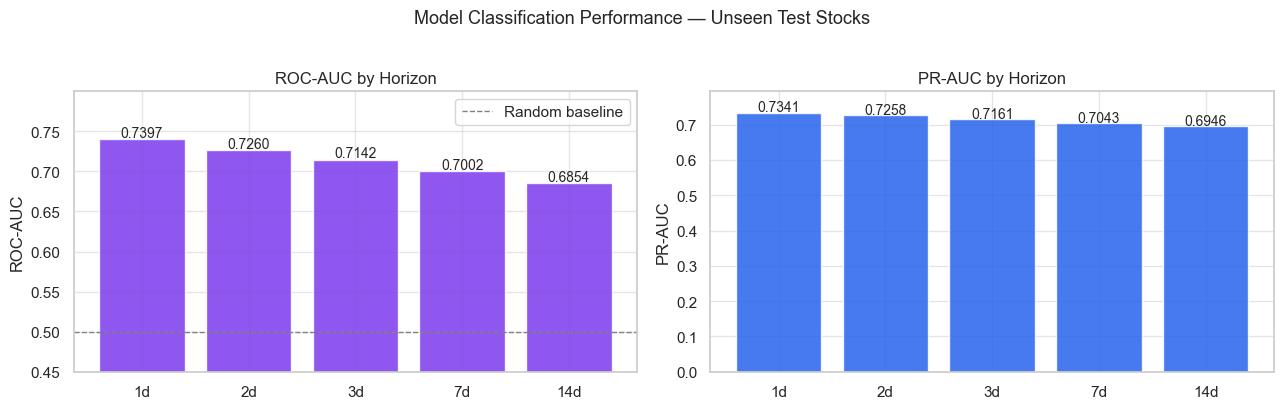

In [7]:
if horizon_results:
    h_list  = list(horizon_results.keys())
    aucs    = [horizon_results[d]['auc'] for d in h_list]
    pr_aucs = [horizon_results[d]['ap']  for d in h_list]
    labels  = [f'{d}d' for d in h_list]
    x = range(len(labels))

    fig, axes = plt.subplots(1, 2, figsize=(13, 4))

    axes[0].bar(x, aucs, color='#7c3aed', alpha=0.85)
    axes[0].axhline(0.5, linestyle='--', color='gray', lw=1, label='Random baseline')
    axes[0].set_xticks(x); axes[0].set_xticklabels(labels)
    axes[0].set_ylabel('ROC-AUC'); axes[0].set_title('ROC-AUC by Horizon')
    axes[0].set_ylim(0.45, max(aucs) + 0.06)
    for xi, v in zip(x, aucs):
        axes[0].text(xi, v + 0.003, f'{v:.4f}', ha='center', fontsize=10)
    axes[0].legend()

    axes[1].bar(x, pr_aucs, color='#2563eb', alpha=0.85)
    axes[1].set_xticks(x); axes[1].set_xticklabels(labels)
    axes[1].set_ylabel('PR-AUC'); axes[1].set_title('PR-AUC by Horizon')
    axes[1].set_ylim(0, max(pr_aucs) + 0.06)
    for xi, v in zip(x, pr_aucs):
        axes[1].text(xi, v + 0.003, f'{v:.4f}', ha='center', fontsize=10)

    plt.suptitle('Model Classification Performance — Unseen Test Stocks', y=1.02, fontsize=13)
    plt.tight_layout(); plt.show()

---
## 4. Precision-Recall Curves

The PR curve plots **Precision** (what fraction of our Buy calls are correct) against
**Recall** (what fraction of actual Up days we caught).

For a trading strategy, **Precision matters more than Recall**:
- Missing an opportunity (low recall) means we stay in cash — a neutral outcome.
- False positives (low precision) means we enter a losing trade — an active loss.

That is why the trading threshold (0.70) is intentionally **above** the max-F1 threshold
shown on each chart: we sacrifice recall to gain precision.


════════════════════════════════════════════════════════════
SECTION 3 — Precision-Recall Curves (all horizons)
════════════════════════════════════════════════════════════


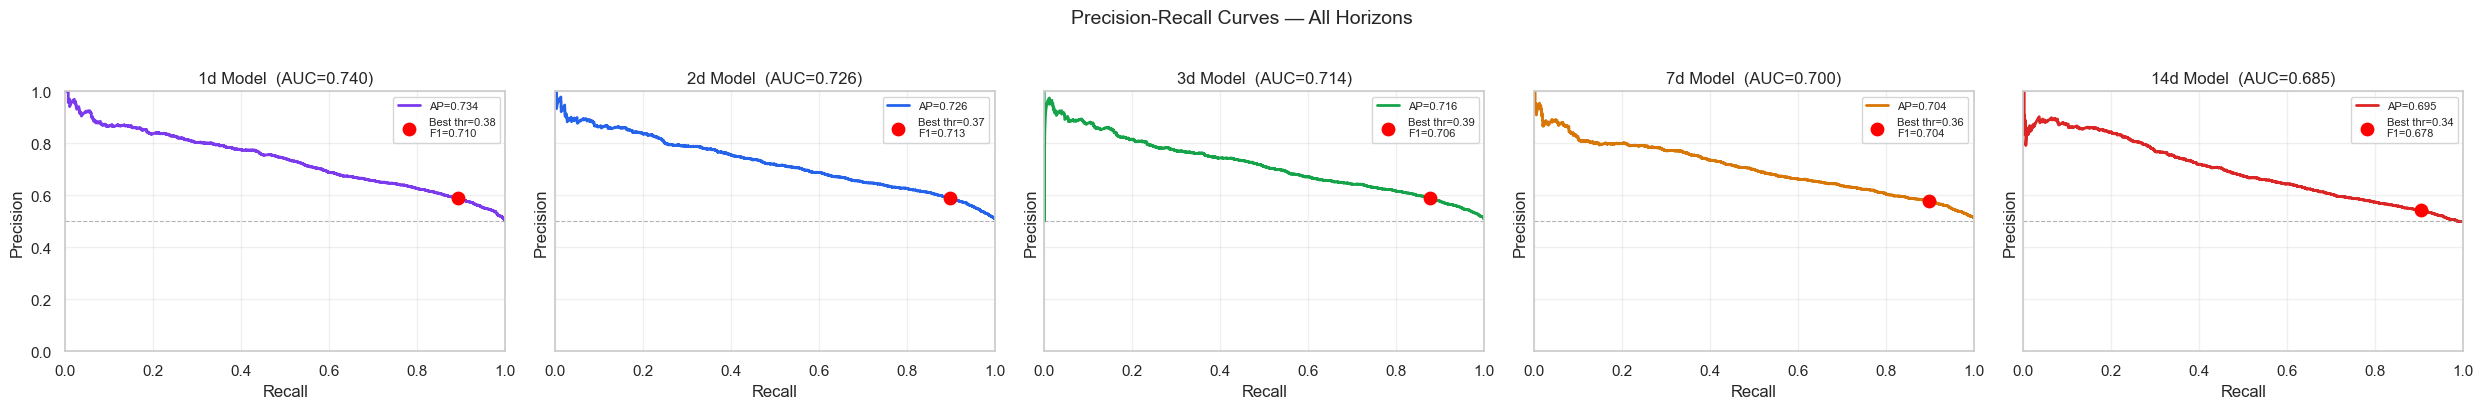

In [8]:
if horizon_results:
    PR2.section3_pr_curves(horizon_results)

---
## 5. Confusion Matrix (1d Model)

Using the optimal threshold (max F1) on the unseen test set.

**Interpreting the cells in a trading context:**

| Cell | Label | Trading Impact |
|------|-------|----------------|
| Top-left | True Negative | We stayed out; stock fell — correct avoidance |
| Top-right | False Positive | We entered; stock fell — **realized loss** |
| Bottom-left | False Negative | We stayed out; stock rose — missed opportunity (opportunity cost only) |
| Bottom-right | True Positive | We entered; stock rose — **realized gain** |

A good trading model should maximize True Positives and minimize False Positives.
The asymmetry matters: a 50% win rate can still be profitable if the average win
is larger than the average loss (positive expectancy).

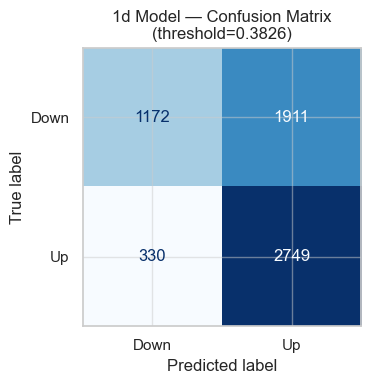

In [9]:
if horizon_results:
    PR2.section4_confusion_matrix(horizon_results, primary_days=1)

---
## 6. Calibration Analysis

**Is the model well-calibrated?** This is a question distinct from accuracy.

A model with AUC = 0.58 might still be *poorly calibrated* — meaning Prob = 0.80
and Prob = 0.55 lead to the same actual return distribution. If that is the case,
the threshold choice becomes arbitrary and the model has no real edge at high confidence.

**What we want to see**: monotonically increasing mean return as probability bin increases.
Specifically, the bins above 0.60 should show positive average returns and the bins
below 0.40 should show negative (or near-zero) average returns.

**If calibration fails**: the model is labeling certain patterns as 'Up' but those patterns
do not actually predict up moves. This often signals overfitting to a specific regime,
or feature leakage. In this case, retraining with a larger training window or more
regularization is recommended before using the model for live trading.

In [10]:
cal_stats = PR2.section2_calibration(target_days=1)


════════════════════════════════════════════════════════════
SECTION 2 — Calibration Analysis (1d model)
════════════════════════════════════════════════════════════

  Probability Bin   Mean Return (%)   Std (%)   Count
  ────────────────────────────────────────────────────────
         0.0–0.1           -1.861      2.130      120
         0.1–0.2           -1.233      1.681      361
         0.2–0.3           -0.771      1.587      764
         0.3–0.4           -0.403      1.689     1332
         0.4–0.5           -0.104      1.824     1824
         0.5–0.6           +0.091      1.822     1966
         0.6–0.7           +0.452      1.803     1613
         0.7–0.8           +0.636      1.661     1057
         0.8–0.9           +0.944      1.611      487
         0.9–1.0           +1.839      2.026      130

  High-confidence bins (0.5–1.0) avg return: +0.793%
  Low-confidence  bins (0.0–0.5) avg return: -0.874%
  ✓ Model is calibrated: higher prob → higher return


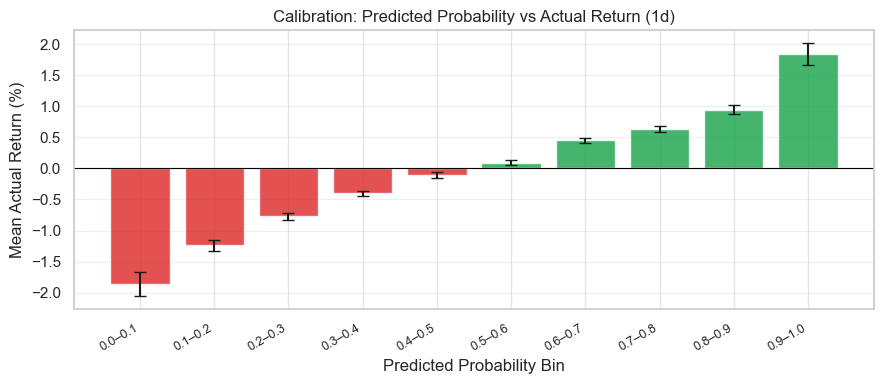

In [11]:
if cal_stats is not None:
    PR2.plot_calibration_chart(cal_stats, target_days=1)

---
## 7. Backtest Simulation

### Design Principles

1. **Out-of-sample stocks**: randomly sampled from non-training stocks (`RANDOM_SEED=33`)
2. **Time-based split**: only bars after `EVAL_START_DATE` are traded
3. **Realistic costs**: fee + tax + slippage applied symmetrically on both sides
4. **Fair benchmark**: Buy-and-Hold also pays the same entry/exit costs

### Reading the Metrics

| Metric | What it means | Target |
|--------|--------------|--------|
| Total Return | Cumulative return over the eval period | > B&H |
| CAGR | Annualized compound return | > 10% |
| Sharpe Ratio | Excess return per unit of daily volatility (annualized) | > 1.0 |
| Max Drawdown | Largest peak-to-trough decline | < 20% |
| Profit Factor | Gross profit / Gross loss across all trades | > 1.5 |
| Win Rate | Fraction of trades with positive return | > 50% |

**Important caveat — regime overlap**:
Even though test stocks are different from training stocks, the model was trained on ALL historical
dates including the evaluation period. Using `EVAL_START_DATE` limits this but does not eliminate it.
A fully clean test would require retraining with data only up to `EVAL_START_DATE`.

**Why CAGR alone is insufficient**: a strategy that goes all-in once and doubles
in a bull run has a high CAGR but is not repeatable. Sharpe Ratio + Max Drawdown together
tell you whether the strategy is achieving its returns through skill or through luck/risk.

In [12]:
bt_models = {}
for d in HORIZONS:
    if available_models[d]['exists']:
        bt_models[d] = joblib.load(available_models[d]['path'])
        print(f'  Loaded {d}d model  ({available_models[d]["size_mb"]:.1f} MB)')

test_stocks = BT2.sample_test_stocks(n=BT2.N_TEST_STOCKS, seed=BT2.RANDOM_SEED)
print(f'\nTest stocks (seed={BT2.RANDOM_SEED}): {test_stocks}')
print(f'Eval window : {BT2.EVAL_START_DATE} -> latest')
print(f'Buy > {BT2.BUY_THRESHOLD:.0%}   Sell < {BT2.SELL_THRESHOLD:.0%}')

  Loaded 1d model  (1.9 MB)
  Loaded 2d model  (1.9 MB)
  Loaded 3d model  (1.9 MB)
  Loaded 7d model  (1.9 MB)
  Loaded 14d model  (1.9 MB)

Test stocks (seed=33): ['6005', '2399', '6241', '2726', '9929', '2948', '3041', '4907', '6419', '6958']
Eval window : 2025-01-01 -> latest
Buy > 70%   Sell < 40%


In [13]:
bt_results = {}

for days, model in bt_models.items():
    print(f'\n-- {days}d Model ---')
    for stock_id in test_stocks:
        if stock_id not in bt_results:
            bt_results[stock_id] = {}
        equity_df, trades_df = BT2.run_backtest(stock_id, model, target_days=days)
        if equity_df is None:
            continue
        strat_m = BT2.compute_metrics(equity_df['Strategy'],  trades_df,      'Strategy', BT2.INITIAL_CAPITAL)
        bench_m = BT2.compute_metrics(equity_df['Benchmark'], pd.DataFrame(), 'B&H',      BT2.INITIAL_CAPITAL)
        bt_results[stock_id][days] = {'strat': strat_m, 'bench': bench_m,
                                       'equity_df': equity_df, 'trades_df': trades_df}
        tr  = strat_m.get('Total Return', 'N/A')
        btr = bench_m.get('Total Return', 'N/A')
        shr = strat_m.get('Sharpe Ratio', 'N/A')
        nt  = strat_m.get('Num Trades', 0)
        print(f'  {stock_id}  Strat={tr:>8}  B&H={btr:>8}  Sharpe={shr}  Trades={nt}')

print('\nBacktest complete.')


-- 1d Model ---
  6005  Strat= +21.36%  B&H= +33.56%  Sharpe=0.73  Trades=13
  2399  Strat= +66.00%  B&H= +86.03%  Sharpe=1.46  Trades=19
  6241  Strat= +30.25%  B&H= -36.38%  Sharpe=1.02  Trades=13
  2726  Strat=  +2.69%  B&H= -66.26%  Sharpe=0.12  Trades=17
  9929  Strat= +34.01%  B&H= -29.62%  Sharpe=1.03  Trades=6
  2948  Strat=  +4.82%  B&H= -11.63%  Sharpe=0.45  Trades=6
  3041  Strat=  -7.60%  B&H= -29.11%  Sharpe=-0.20  Trades=15
  4907  Strat= +21.64%  B&H= -49.18%  Sharpe=0.83  Trades=9
  6419  Strat= +82.46%  B&H= +39.29%  Sharpe=1.20  Trades=13
  6958  Strat= +30.43%  B&H= -26.55%  Sharpe=1.24  Trades=12

-- 2d Model ---
  6005  Strat= +66.25%  B&H= +26.12%  Sharpe=1.81  Trades=14
  2399  Strat=  +7.28%  B&H= +95.72%  Sharpe=0.28  Trades=13
  6241  Strat=  -8.38%  B&H= -34.80%  Sharpe=-0.42  Trades=9
  2726  Strat=  -9.94%  B&H= -66.15%  Sharpe=-0.28  Trades=9
  9929  Strat= +18.22%  B&H= -26.52%  Sharpe=1.10  Trades=6
  2948  Strat= -25.73%  B&H= -13.66%  Sharpe=-2.26  Tr

In [14]:
active_horizons = list(bt_models.keys())
BT2.print_multi_horizon_summary(bt_results, active_horizons)


══════════════════════════════════════════════════════════════════════════════════════
SUMMARY — Total Return by Horizon
══════════════════════════════════════════════════════════════════════════════════════
   Stock          B&H     1d Strat     2d Strat     3d Strat     7d Strat    14d Strat
  ────────────────────────────────────────────────────────────────────────────────────
    6005      +33.56%      +21.36%      +66.25%       +5.82%      -18.85%       -3.40%
    2399      +86.03%      +66.00%       +7.28%      +57.06%      +30.59%       +3.44%
    6241      -36.38%      +30.25%       -8.38%      +17.45%      +24.83%       +3.06%
    2726      -66.26%       +2.69%       -9.94%       -9.85%      -10.28%       -4.10%
    9929      -29.62%      +34.01%      +18.22%       +9.03%      +16.32%      +11.27%
    2948      -11.63%       +4.82%      -25.73%      -12.85%       -1.52%       -3.35%
    3041      -29.11%       -7.60%       -3.13%      -22.12%       -1.57%      -14.17%
    4907

In [15]:
BT2.plot_multi_horizon_summary(bt_results, active_horizons)

In [16]:
if 1 in bt_models:
    for stock_id, stock_res in bt_results.items():
        if 1 not in stock_res:
            continue
        r = stock_res[1]
        BT2.plot_results(stock_id, r['equity_df'], r['trades_df'], r['strat'], r['bench'])

Total trades (1d, all stocks): 123
Win rate     : 56.91%
Avg return   : +1.9837%
Avg hold     : 9.4 days


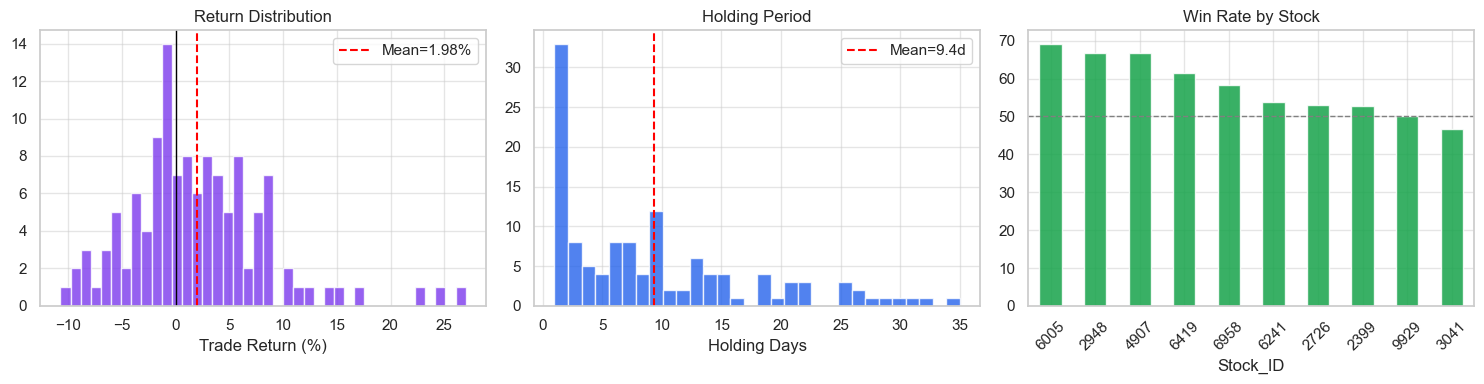

In [17]:
all_trades = []
for stock_id, stock_res in bt_results.items():
    if 1 not in stock_res or stock_res[1]['trades_df'].empty:
        continue
    td = stock_res[1]['trades_df'].copy()
    td['Stock_ID'] = stock_id
    all_trades.append(td)

if all_trades:
    trades_all = pd.concat(all_trades, ignore_index=True)
    print(f'Total trades (1d, all stocks): {len(trades_all)}')
    print(f'Win rate     : {(trades_all["return_pct"] > 0).mean():.2%}')
    print(f'Avg return   : {trades_all["return_pct"].mean():+.4%}')
    print(f'Avg hold     : {trades_all["holding_days"].mean():.1f} days')

    fig, axes = plt.subplots(1, 3, figsize=(15, 4))

    ret_pct = trades_all['return_pct'] * 100
    axes[0].hist(ret_pct, bins=40, color='#7c3aed', alpha=0.8, edgecolor='white')
    axes[0].axvline(0, color='black', lw=1)
    axes[0].axvline(ret_pct.mean(), color='red', lw=1.5, ls='--', label=f'Mean={ret_pct.mean():.2f}%')
    axes[0].set_xlabel('Trade Return (%)'); axes[0].set_title('Return Distribution'); axes[0].legend()

    axes[1].hist(trades_all['holding_days'], bins=30, color='#2563eb', alpha=0.8, edgecolor='white')
    axes[1].axvline(trades_all['holding_days'].mean(), color='red', lw=1.5, ls='--',
                    label=f'Mean={trades_all["holding_days"].mean():.1f}d')
    axes[1].set_xlabel('Holding Days'); axes[1].set_title('Holding Period'); axes[1].legend()

    per_wr = (trades_all.groupby('Stock_ID')
              .apply(lambda g: (g['return_pct'] > 0).mean() * 100)
              .sort_values(ascending=False))
    per_wr.plot(kind='bar', ax=axes[2], color='#16a34a', alpha=0.85)
    axes[2].axhline(50, ls='--', color='gray', lw=1)
    axes[2].set_title('Win Rate by Stock'); axes[2].tick_params(axis='x', rotation=45)

    plt.tight_layout(); plt.show()

---
## 8. Buy / Sell Threshold Sensitivity

The original thresholds (Buy > 0.70, Sell < 0.35) were chosen to prioritize precision
over trade frequency. This section asks: **how sensitive is performance to that choice?**

We sweep all combinations of buy threshold ∈ {0.55, 0.60, ..., 0.80} ×
sell threshold ∈ {0.25, 0.30, ..., 0.45} on **every test stock** and aggregate the results.

**What to watch for in the averaged heatmaps:**
- A wide region of positive returns (robust, not just lucky on one stock)
- Sharpe Ratio increasing as buy threshold rises — higher threshold = better precision per trade
- Returns collapsing at very high buy threshold (too few trades, missing most moves)
- Returns collapsing at very low buy threshold (too much noise)

**Per-stock bar chart**: shows where each individual stock's performance lands at the current
threshold vs. its own optimal. Wide variance across stocks means the optimal threshold
is stock-dependent and we should not chase it — the averaged heatmap is the reliable guide.

**Stock × Buy-threshold heatmap**: reveals whether some stocks respond very differently
to threshold changes — useful for understanding model sensitivity by security.

In [18]:
def run_threshold_sweep(stock_id, model, buy_thresholds, sell_thresholds):
    def _pct(s):
        try: return float(str(s).rstrip('%').replace('+', ''))
        except: return 0.0
    orig_bt = BT2.BUY_THRESHOLD; orig_st = BT2.SELL_THRESHOLD
    records = []
    for bt in buy_thresholds:
        for st in sell_thresholds:
            if bt <= st: continue
            BT2.BUY_THRESHOLD = bt; BT2.SELL_THRESHOLD = st
            eq, tr = BT2.run_backtest(stock_id, model, target_days=1)
            if eq is None: continue
            m = BT2.compute_metrics(eq['Strategy'], tr, 'Strategy', BT2.INITIAL_CAPITAL)
            if not m: continue
            records.append({'Buy_Thr': bt, 'Sell_Thr': st,
                             'Return_%':  _pct(m.get('Total Return', '0%')),
                             'Sharpe':    float(m.get('Sharpe Ratio', 0)),
                             'MaxDD_%':   _pct(m.get('Max Drawdown',  '0%')),
                             'Trades':    int(m.get('Num Trades', 0)),
                             'WinRate_%': _pct(m.get('Win Rate',     '0%'))})
    BT2.BUY_THRESHOLD = orig_bt; BT2.SELL_THRESHOLD = orig_st
    return pd.DataFrame(records)

# Run sweep on every test stock with the 1d model
BUY_RANGE  = [0.55, 0.60, 0.65, 0.70, 0.75, 0.80]
SELL_RANGE = [0.25, 0.30, 0.35, 0.40, 0.45]
sweep_results = {}

if 1 in bt_models:
    for stock_id in test_stocks:
        sdf = run_threshold_sweep(stock_id, bt_models[1], BUY_RANGE, SELL_RANGE)
        if not sdf.empty:
            sweep_results[stock_id] = sdf
            print(f'  {stock_id}: {len(sdf)} threshold combos')

    if sweep_results:
        all_sweeps = pd.concat([df.assign(Stock_ID=sid) for sid, df in sweep_results.items()])
        avg_sweep  = (all_sweeps.groupby(['Buy_Thr', 'Sell_Thr'])
                      .agg(Return_avg  = ('Return_%',  'mean'),
                           Sharpe_avg  = ('Sharpe',    'mean'),
                           Trades_avg  = ('Trades',    'mean'),
                           WinRate_avg = ('WinRate_%', 'mean'))
                      .reset_index())
        print(f'\nAveraged across {len(sweep_results)} stocks:')
        display(avg_sweep.sort_values('Return_avg', ascending=False).head(15))
    else:
        avg_sweep = pd.DataFrame(); print('No sweep results.')
else:
    sweep_results = {}; avg_sweep = pd.DataFrame(); print('1d model not available.')

  6005: 30 threshold combos
  2399: 30 threshold combos
  6241: 30 threshold combos
  2726: 30 threshold combos
  9929: 30 threshold combos
  2948: 30 threshold combos
  3041: 30 threshold combos
  4907: 30 threshold combos
  6419: 30 threshold combos
  6958: 30 threshold combos

Averaged across 10 stocks:


,Buy_Thr,Sell_Thr,Return_avg,Sharpe_avg,Trades_avg,WinRate_avg
21,0.75,0.30,34.042,0.459,4.6,56.001
22,0.75,0.35,30.508,0.690,6.4,56.727
20,0.75,0.25,30.153,0.197,3.3,39.333
18,0.70,0.40,28.606,0.788,12.3,57.853
23,0.75,0.40,23.171,0.941,7.4,63.001
17,0.70,0.35,22.374,0.326,10.1,51.249
2,0.55,0.35,20.517,0.109,21.2,49.593
7,0.60,0.35,19.596,0.116,17.9,49.636
24,0.75,0.45,18.390,1.016,7.7,56.909
19,0.70,0.45,16.699,0.733,13.7,50.517


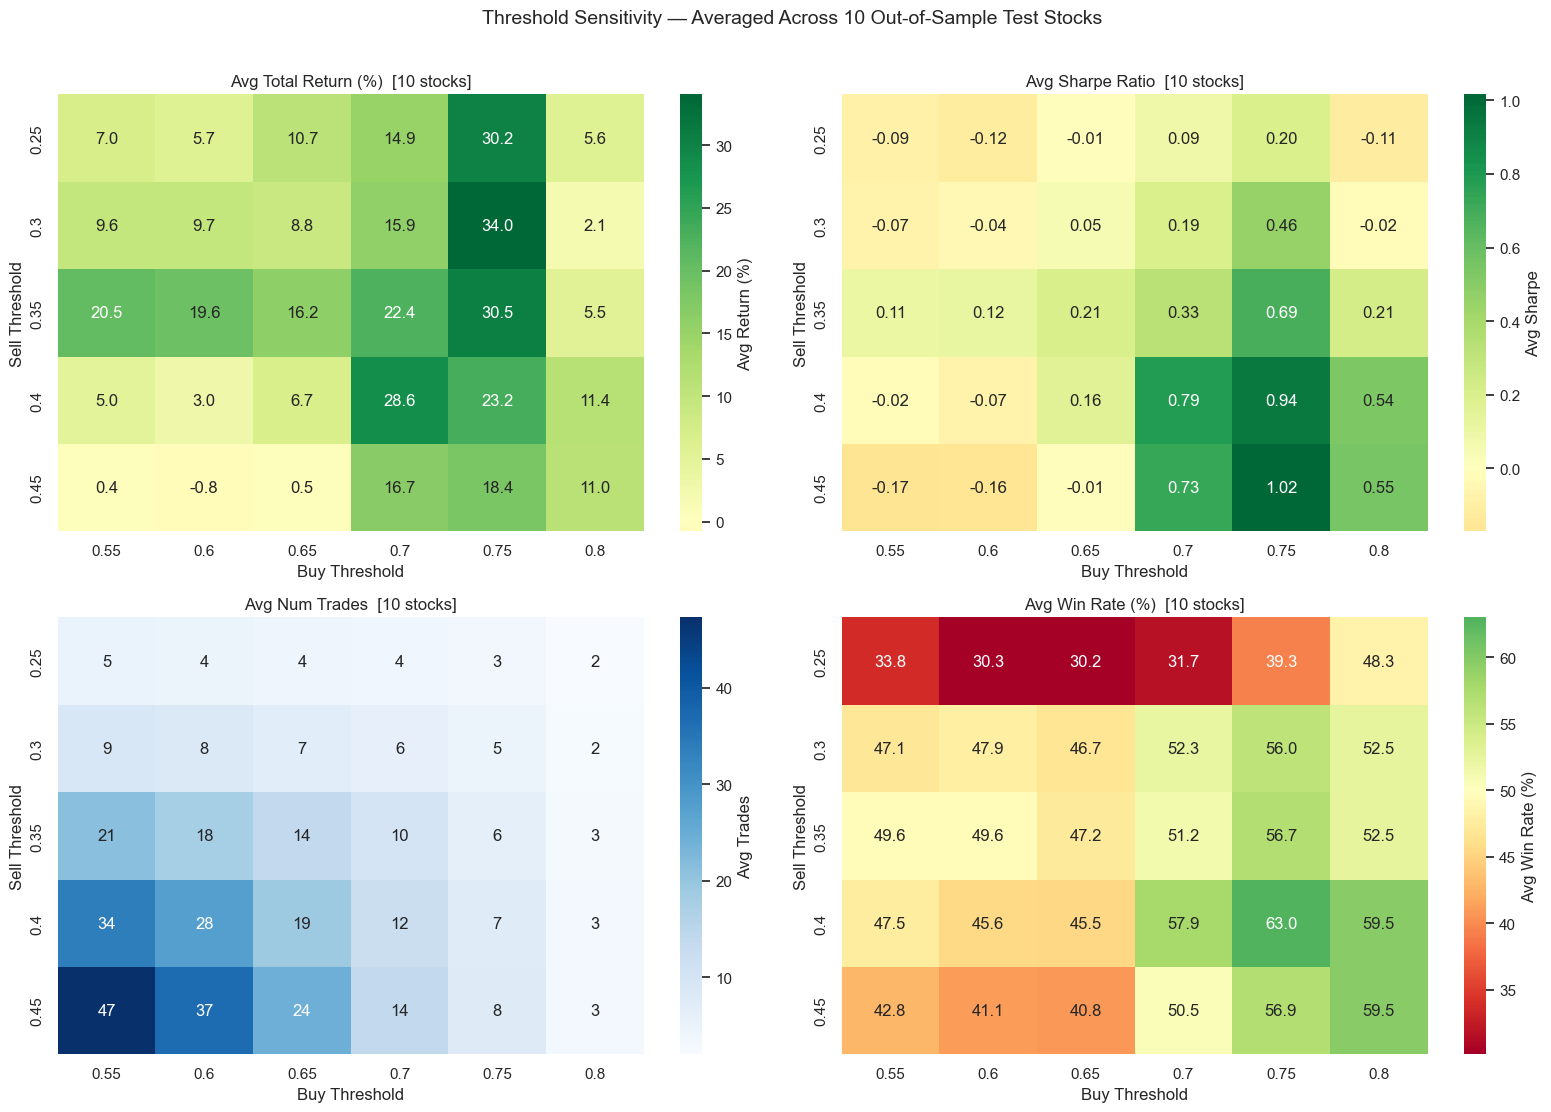

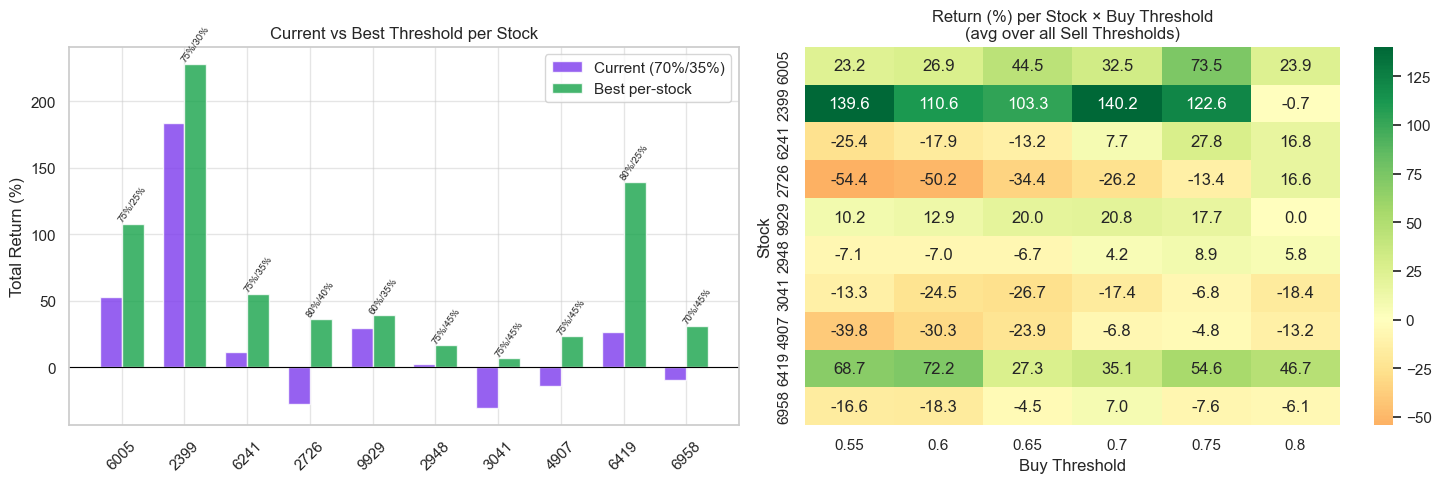

Current setting  : Buy>70%  Sell<35%
Best avg Return  : Buy>75%  Sell<30%  -> +34.04%  Sharpe=0.46
Best avg Sharpe  : Buy>75%  Sell<45%  -> +18.39%  Sharpe=1.02


In [19]:
if not avg_sweep.empty and sweep_results:
    n = len(sweep_results)

    # ── 4-panel averaged heatmaps ─────────────────────────────────────────────
    fig, axes = plt.subplots(2, 2, figsize=(16, 11))

    def _hmap(ax, data, title, label, fmt, center, cmap='RdYlGn'):
        sns.heatmap(data, annot=True, fmt=fmt, cmap=cmap, center=center,
                    ax=ax, cbar_kws={'label': label})
        ax.set_title(title); ax.set_xlabel('Buy Threshold'); ax.set_ylabel('Sell Threshold')

    _hmap(axes[0][0],
          avg_sweep.pivot(index='Sell_Thr', columns='Buy_Thr', values='Return_avg'),
          f'Avg Total Return (%)  [{n} stocks]', 'Avg Return (%)', '.1f', 0)
    _hmap(axes[0][1],
          avg_sweep.pivot(index='Sell_Thr', columns='Buy_Thr', values='Sharpe_avg'),
          f'Avg Sharpe Ratio  [{n} stocks]', 'Avg Sharpe', '.2f', 0)
    _hmap(axes[1][0],
          avg_sweep.pivot(index='Sell_Thr', columns='Buy_Thr', values='Trades_avg'),
          f'Avg Num Trades  [{n} stocks]', 'Avg Trades', '.0f', None, 'Blues')
    _hmap(axes[1][1],
          avg_sweep.pivot(index='Sell_Thr', columns='Buy_Thr', values='WinRate_avg'),
          f'Avg Win Rate (%)  [{n} stocks]', 'Avg Win Rate (%)', '.1f', 50)

    plt.suptitle(f'Threshold Sensitivity — Averaged Across {n} Out-of-Sample Test Stocks',
                 fontsize=14, y=1.01)
    plt.tight_layout(); plt.show()

    # ── Per-stock: current setting vs best threshold ───────────────────────────
    stocks_list = list(sweep_results.keys())
    cur_bt = 0.70; cur_st = 0.35
    cur_rets, best_rets, best_lbls = [], [], []
    for sid in stocks_list:
        sdf     = sweep_results[sid]
        cur_row = sdf[(sdf['Buy_Thr'] == cur_bt) & (sdf['Sell_Thr'] == cur_st)]
        best_r  = sdf.loc[sdf['Return_%'].idxmax()]
        cur_rets.append(float(cur_row['Return_%'].values[0]) if len(cur_row) else 0)
        best_rets.append(float(best_r['Return_%']))
        best_lbls.append(f'{best_r["Buy_Thr"]:.0%}/{best_r["Sell_Thr"]:.0%}')

    fig2, axes2 = plt.subplots(1, 2, figsize=(15, 5))

    w = 0.35; x = list(range(len(stocks_list)))
    axes2[0].bar([i - w/2 for i in x], cur_rets,  w, label='Current (70%/35%)', color='#7c3aed', alpha=0.8)
    axes2[0].bar([i + w/2 for i in x], best_rets, w, label='Best per-stock',    color='#16a34a', alpha=0.8)
    axes2[0].axhline(0, color='black', lw=0.8)
    axes2[0].set_xticks(x); axes2[0].set_xticklabels(stocks_list, rotation=45)
    axes2[0].set_ylabel('Total Return (%)'); axes2[0].set_title('Current vs Best Threshold per Stock')
    axes2[0].legend()
    for i, (b, lb) in enumerate(zip(best_rets, best_lbls)):
        axes2[0].text(i + w/2, b + 0.5, lb, ha='center', va='bottom', fontsize=7, rotation=55)

    # Per-stock × buy threshold heatmap (avg over sell thresholds)
    stock_bt = pd.concat(
        [sweep_results[sid].groupby('Buy_Thr')['Return_%'].mean().rename(sid) for sid in stocks_list],
        axis=1).T
    sns.heatmap(stock_bt, annot=True, fmt='.1f', cmap='RdYlGn', center=0, ax=axes2[1])
    axes2[1].set_title('Return (%) per Stock × Buy Threshold\n(avg over all Sell Thresholds)')
    axes2[1].set_xlabel('Buy Threshold'); axes2[1].set_ylabel('Stock')

    plt.tight_layout(); plt.show()

    # Summary
    best_r = avg_sweep.loc[avg_sweep['Return_avg'].idxmax()]
    best_s = avg_sweep.loc[avg_sweep['Sharpe_avg'].idxmax()]
    print(f'Current setting  : Buy>70%  Sell<35%')
    print(f'Best avg Return  : Buy>{best_r["Buy_Thr"]:.0%}  Sell<{best_r["Sell_Thr"]:.0%}',
          f' -> {best_r["Return_avg"]:+.2f}%  Sharpe={best_r["Sharpe_avg"]:.2f}')
    print(f'Best avg Sharpe  : Buy>{best_s["Buy_Thr"]:.0%}  Sell<{best_s["Sell_Thr"]:.0%}',
          f' -> {best_s["Return_avg"]:+.2f}%  Sharpe={best_s["Sharpe_avg"]:.2f}')

---
## 9. Multi-Horizon Signal Interaction Analysis

The five horizon models each encode a different time-scale view of the market.
**They do not always agree** — and that disagreement carries information.

This section systematically answers the question:

> *If the 14d model is bullish but the 1d model is bearish — should I buy or avoid?*

### The Four Signal Quadrants (1d × 14d)

| Quadrant | 1d Prob | 14d Prob | Interpretation | Suggested Action |
|----------|---------|---------|----------------|-----------------|
| **A: Both High** | > 0.58 | > 0.58 | Full alignment — near-term momentum + medium-term trend both positive | **Strong buy** with normal position size |
| **B: 14d High, 1d Low** | < 0.45 | > 0.58 | Medium-term uptrend intact, but near-term weakness (dip, consolidation) | **Dip buy** — enter at a better price, expecting the longer trend to resume |
| **C: 1d High, 14d Low** | > 0.58 | < 0.45 | Short-term bounce in a medium-term downtrend | **Caution** — if you enter, keep position small and exit quickly |
| **D: Both Low** | < 0.45 | < 0.45 | Both time-scales bearish — no edge | **Avoid / hold cash** |

### Practical Decision Tree

```
START: you want to decide whether to enter a stock today
  |
  +-- 14d Prob < 0.45?  -->  AVOID (quadrant D or C)
  |
  +-- 14d Prob > 0.58?
        |
        +-- 1d Prob > 0.58?  -->  STRONG BUY (quadrant A)
        |
        +-- 1d Prob < 0.45?  -->  DIP BUY, smaller size (quadrant B)
        |
        +-- 0.45 < 1d < 0.58? --> NEUTRAL, wait for clarity
```

**Key hypothesis**: Quadrant B (14d High, 1d Low) should show *better forward returns*
than Quadrant A over the 14-day horizon, because we are entering at a temporarily
depressed price within an ongoing uptrend.

The cells below test this hypothesis against historical data.

In [20]:
# Section 9 computes probs by re-running the models on the full historical data
# of each test stock, giving multi-year (prob, actual_return) pairs.
# daily_predictions only stores the most recent batch — not enough for statistics.

def compute_multi_horizon_history(stock_id, models_dict, db_path):
    '''
    Re-run all horizon models on the full history of one stock.
    Returns a DataFrame: Prob_Nd cols, Return_1d, Return_14d, Stock_ID.
    '''
    drop_cols = ['Open', 'High', 'Low', 'Close', 'Volume', 'Type', 'Stock_ID', 'Future_Return']
    prob_series = {}

    for days, model in models_dict.items():
        df_h = prepare_training_data_v2(stock_id, target_days=days, path=db_path, keep_raw_prices=True)
        if df_h is None or df_h.empty:
            continue
        df_h = df_h.dropna(subset=['Future_Return'])
        X = df_h.drop(columns=[c for c in drop_cols if c in df_h.columns])
        X = X.select_dtypes(include=[np.number]).replace([np.inf, -np.inf], np.nan).fillna(0)
        prob_series[f'Prob_{days}d'] = pd.Series(model.predict_proba(X)[:, 1], index=df_h.index)

    if not prob_series:
        return pd.DataFrame()

    result = pd.DataFrame(prob_series)

    # Attach actual 1d forward return
    df_1d = prepare_training_data_v2(stock_id, target_days=1, path=db_path, keep_raw_prices=False)
    if df_1d is not None and not df_1d.empty:
        result['Return_1d'] = df_1d['Future_Return'].reindex(result.index)

    # Attach actual 14d forward return
    df_14 = prepare_training_data_v2(stock_id, target_days=14, path=db_path, keep_raw_prices=False)
    if df_14 is not None and not df_14.empty:
        result['Return_14d'] = df_14['Future_Return'].reindex(result.index)

    result['Stock_ID'] = stock_id
    return result.dropna(subset=['Prob_1d', 'Return_1d'])

# Also load prices_raw and dp — needed by Section 11 (multi-strategy backtest)
conn = sqlite3.connect(DB_PATH)
try:
    dp = pd.read_sql('SELECT * FROM daily_predictions', conn)
    dp['Date'] = pd.to_datetime(dp['Date']); has_dp = not dp.empty
except:
    dp = pd.DataFrame(); has_dp = False
prices_raw = pd.read_sql(
    'SELECT Stock_ID, Date, Close FROM tw_stock_prices ORDER BY Stock_ID, Date', conn)
prices_raw['Date'] = pd.to_datetime(prices_raw['Date'])
conn.close()

# Compute multi-horizon history for all test stocks
print('Computing multi-horizon probability history on test stocks...')
all_hist = []
for stock_id in test_stocks:
    print(f'  {stock_id}...', end=' ', flush=True)
    hist = compute_multi_horizon_history(stock_id, bt_models, DB_PATH)
    if not hist.empty:
        all_hist.append(hist)
        print(f'{len(hist)} rows')
    else:
        print('skipped')

if all_hist:
    analysis_df = pd.concat(all_hist)
    has_hist = True
    print(f'\nTotal rows : {len(analysis_df):,}')
    print(f'Date range : {analysis_df.index.min().date()}  ->  {analysis_df.index.max().date()}')
    print(f'Stocks     : {analysis_df["Stock_ID"].nunique()}')
    display(analysis_df[['Prob_1d', 'Prob_14d', 'Return_1d', 'Return_14d', 'Stock_ID']].head(5))
else:
    analysis_df = pd.DataFrame(); has_hist = False
    print('No data — ensure bt_models is populated (run Section 7 first).')

Computing multi-horizon probability history on test stocks...
  6005... 1206 rows
  2399... 1206 rows
  6241... 1179 rows
  2726... 1124 rows
  9929... 1076 rows
  2948... 581 rows
  3041... 1192 rows
  4907... 1154 rows
  6419... 1127 rows
  6958... 637 rows

Total rows : 10,482
Date range : 2021-06-02  ->  2026-05-27
Stocks     : 10


,Prob_1d,Prob_14d,Return_1d,Return_14d,Stock_ID
Date,,,,,
2021-06-02,0.373675,0.378234,0.002825,-0.067797,6005
2021-06-03,0.374700,0.407024,-0.014085,-0.050704,6005
2021-06-04,0.315431,0.466137,-0.022857,-0.045714,6005
2021-06-07,0.420863,0.365251,-0.005848,-0.014620,6005
2021-06-08,0.287734,0.453184,-0.014706,-0.020588,6005


=== Historical Analysis Dataset ===
Rows with Return_1d  : 10,482
Rows with Return_14d : 10,357
Prob_1d  range  : [0.039, 0.964]
Prob_14d range  : [0.043, 0.957]


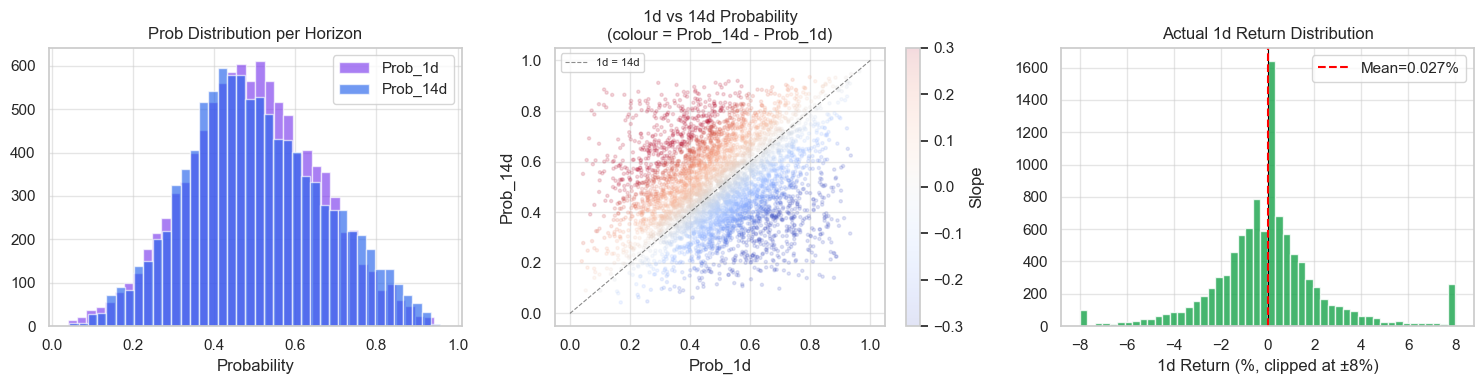

In [21]:
# Data quality check and distribution visualisation
if has_hist:
    print('=== Historical Analysis Dataset ===')
    print(f'Rows with Return_1d  : {analysis_df["Return_1d"].notna().sum():,}')
    print(f'Rows with Return_14d : {analysis_df["Return_14d"].notna().sum():,}')
    print(f'Prob_1d  range  : [{analysis_df["Prob_1d"].min():.3f}, {analysis_df["Prob_1d"].max():.3f}]')
    print(f'Prob_14d range  : [{analysis_df["Prob_14d"].min():.3f}, {analysis_df["Prob_14d"].max():.3f}]')

    fig, axes = plt.subplots(1, 3, figsize=(15, 4))

    # Prob distributions
    axes[0].hist(analysis_df['Prob_1d'],  bins=40, color='#7c3aed', alpha=0.65, label='Prob_1d')
    axes[0].hist(analysis_df['Prob_14d'], bins=40, color='#2563eb', alpha=0.65, label='Prob_14d')
    axes[0].set_xlabel('Probability'); axes[0].set_title('Prob Distribution per Horizon')
    axes[0].legend()

    # 1d vs 14d scatter (colour = prob difference)
    sample = analysis_df.sample(min(5000, len(analysis_df)), random_state=42)
    sc = axes[1].scatter(sample['Prob_1d'], sample['Prob_14d'],
                         alpha=0.15, s=5, c=sample['Prob_14d'] - sample['Prob_1d'],
                         cmap='coolwarm', vmin=-0.3, vmax=0.3)
    axes[1].plot([0, 1], [0, 1], 'k--', lw=0.8, alpha=0.5, label='1d = 14d')
    axes[1].set_xlabel('Prob_1d'); axes[1].set_ylabel('Prob_14d')
    axes[1].set_title('1d vs 14d Probability\n(colour = Prob_14d - Prob_1d)')
    plt.colorbar(sc, ax=axes[1], label='Slope')
    axes[1].legend(fontsize=8)

    # Return_1d distribution
    ret_pct = analysis_df['Return_1d'].dropna() * 100
    axes[2].hist(ret_pct.clip(-8, 8), bins=50, color='#16a34a', alpha=0.8, edgecolor='white')
    axes[2].axvline(0, color='black', lw=0.8)
    axes[2].axvline(ret_pct.mean(), color='red', lw=1.5, ls='--',
                    label=f'Mean={ret_pct.mean():.3f}%')
    axes[2].set_xlabel('1d Return (%, clipped at ±8%)'); axes[2].set_title('Actual 1d Return Distribution')
    axes[2].legend()

    plt.tight_layout(); plt.show()
else:
    print('No data — run the cell above first.')

In [22]:
if has_hist:
    THR_HIGH = 0.58
    THR_LOW  = 0.45

    def classify_quadrant(p1, p14):
        if p1 > THR_HIGH and p14 > THR_HIGH:   return 'A: Both High'
        if p1 < THR_LOW  and p14 > THR_HIGH:   return 'B: 14d High, 1d Low'
        if p1 > THR_HIGH and p14 < THR_LOW:    return 'C: 1d High, 14d Low'
        if p1 < THR_LOW  and p14 < THR_LOW:    return 'D: Both Low'
        return 'E: Mixed / Neutral'

    analysis_df['Quadrant'] = analysis_df.apply(
        lambda r: classify_quadrant(r['Prob_1d'], r['Prob_14d']), axis=1)

    qstats = analysis_df.groupby('Quadrant', observed=True).agg(
        Count       = ('Return_1d',  'count'),
        WinRate_1d  = ('Return_1d',  lambda x: (x > 0).mean()),
        AvgRet_1d   = ('Return_1d',  'mean'),
        AvgRet_14d  = ('Return_14d', 'mean'),
        WinRate_14d = ('Return_14d', lambda x: (x > 0).mean()),
    )
    for c in ['AvgRet_1d', 'AvgRet_14d']:
        qstats[c + '%'] = (qstats[c] * 100).round(3)
    qstats['WinRate_1d%']  = (qstats['WinRate_1d']  * 100).round(1)
    qstats['WinRate_14d%'] = (qstats['WinRate_14d'] * 100).round(1)

    print('=== Signal Quadrant Statistics ===')
    print(f'Thresholds: HIGH > {THR_HIGH}  |  LOW < {THR_LOW}')
    print(f'Dataset   : {len(analysis_df):,} rows across {analysis_df["Stock_ID"].nunique()} stocks\n')
    display(qstats[['Count', 'WinRate_1d%', 'AvgRet_1d%', 'AvgRet_14d%', 'WinRate_14d%']])
else:
    print('No data — run code-load-dp first.')

=== Signal Quadrant Statistics ===
Thresholds: HIGH > 0.58  |  LOW < 0.45
Dataset   : 10,482 rows across 10 stocks



,Count,WinRate_1d%,AvgRet_1d%,AvgRet_14d%,WinRate_14d%
Quadrant,,,,,
A: Both High,1367,56.4,0.609,3.518,62.3
"B: 14d High, 1d Low",955,35.7,-0.367,2.080,56.2
"C: 1d High, 14d Low",930,52.4,0.528,-1.615,31.7
D: Both Low,2046,32.3,-0.531,-1.893,31.1
E: Mixed / Neutral,5184,42.7,0.077,0.449,43.8


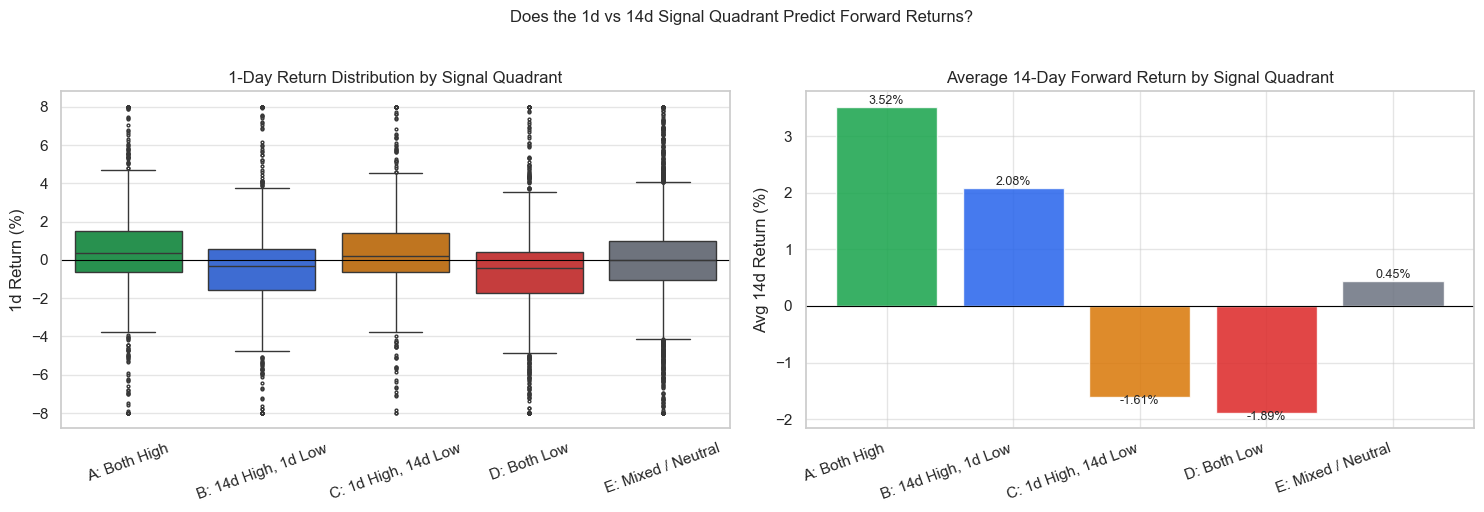


=== Key Findings ===
  A: Both High                  1d avg: +0.609%  14d avg: +3.518%  WR1d: 56.4%  n=1367
  B: 14d High, 1d Low           1d avg: -0.367%  14d avg: +2.080%  WR1d: 35.7%  n=955
  C: 1d High, 14d Low           1d avg: +0.528%  14d avg: -1.615%  WR1d: 52.4%  n=930
  D: Both Low                   1d avg: -0.531%  14d avg: -1.893%  WR1d: 32.3%  n=2046

Quadrant B 14d (+2.080%) vs Quadrant C 14d (-1.615%)
  Confirmed: 14d-High/1d-Low (dip buy) outperforms 1d-High/14d-Low over 14 days.
  => When the long-term model is bullish, short-term weakness is a BUY opportunity.


In [23]:
if has_hist and 'Quadrant' in analysis_df.columns:
    Q_ORDER  = ['A: Both High', 'B: 14d High, 1d Low', 'C: 1d High, 14d Low',
                'D: Both Low', 'E: Mixed / Neutral']
    Q_COLORS = {'A: Both High': '#16a34a', 'B: 14d High, 1d Low': '#2563eb',
                'C: 1d High, 14d Low': '#d97706', 'D: Both Low': '#dc2626',
                'E: Mixed / Neutral': '#6b7280'}

    fig, axes = plt.subplots(1, 2, figsize=(15, 5))

    # Box plot: 1d return by quadrant
    plot_df = analysis_df[analysis_df['Quadrant'].isin(Q_ORDER)].copy()
    plot_df['ret_1d_pct'] = plot_df['Return_1d'].clip(-0.08, 0.08) * 100
    sns.boxplot(data=plot_df, x='Quadrant', y='ret_1d_pct', order=Q_ORDER,
                palette=[Q_COLORS[q] for q in Q_ORDER], ax=axes[0], fliersize=2)
    axes[0].axhline(0, color='black', lw=0.8)
    axes[0].set_title('1-Day Return Distribution by Signal Quadrant')
    axes[0].set_ylabel('1d Return (%)'); axes[0].set_xlabel('')
    axes[0].tick_params(axis='x', rotation=20)

    # Bar: avg 14d return by quadrant
    qplot = qstats.reindex(Q_ORDER).dropna(subset=['AvgRet_14d%'])
    axes[1].bar(range(len(qplot)), qplot['AvgRet_14d%'],
                color=[Q_COLORS.get(q, '#999') for q in qplot.index], alpha=0.85)
    axes[1].axhline(0, color='black', lw=0.8)
    axes[1].set_xticks(range(len(qplot)))
    axes[1].set_xticklabels(qplot.index, rotation=20, ha='right')
    axes[1].set_title('Average 14-Day Forward Return by Signal Quadrant')
    axes[1].set_ylabel('Avg 14d Return (%)')
    for i, v in enumerate(qplot['AvgRet_14d%']):
        axes[1].text(i, v + (0.05 if v >= 0 else -0.12), f'{v:.2f}%', ha='center', fontsize=9)

    plt.suptitle('Does the 1d vs 14d Signal Quadrant Predict Forward Returns?', fontsize=12, y=1.02)
    plt.tight_layout(); plt.show()

    print('\n=== Key Findings ===')
    for q in ['A: Both High', 'B: 14d High, 1d Low', 'C: 1d High, 14d Low', 'D: Both Low']:
        if q in qstats.index:
            r = qstats.loc[q]
            print(f'  {q:<28}  1d avg: {r["AvgRet_1d%"]:+.3f}%  14d avg: {r["AvgRet_14d%"]:+.3f}%  WR1d: {r["WinRate_1d%"]:.1f}%  n={int(r["Count"])}')

    if all(q in qstats.index for q in ['B: 14d High, 1d Low', 'C: 1d High, 14d Low']):
        b14 = qstats.loc['B: 14d High, 1d Low', 'AvgRet_14d%']
        c14 = qstats.loc['C: 1d High, 14d Low', 'AvgRet_14d%']
        print(f'\nQuadrant B 14d ({b14:+.3f}%) vs Quadrant C 14d ({c14:+.3f}%)')
        if b14 > c14:
            print('  Confirmed: 14d-High/1d-Low (dip buy) outperforms 1d-High/14d-Low over 14 days.')
            print('  => When the long-term model is bullish, short-term weakness is a BUY opportunity.')
        else:
            print('  Note: dip-buy (B) did NOT outperform short-term bounce (C) over 14 days in this dataset.')

---
## 10. Horizon Slope Analysis (Prob Momentum)

Beyond the 1d vs 14d quadrant, we can look at the **full shape** of the probability curve
across all five horizons. Define the **horizon slope** as:

```
Prob_Slope = Prob_14d - Prob_1d
```

- **Slope > 0** ("Building"): The model is *more confident* about the longer horizon than the
  near term. This pattern typically corresponds to an **accumulation phase** — the stock is
  consolidating short-term but the longer-term trend is pointing up.
  Action: this is a patient entry — enter and hold, not a quick flip.

- **Slope ≈ 0** ("Flat"): All horizons agree on the same confidence level.
  This is the most reliable regime for the original 1d strategy.

- **Slope < 0** ("Fading"): The model is *less confident* about the longer horizon.
  Short-term momentum exists but is not expected to sustain.
  Pattern: a **distribution phase** — smart money selling into a short-term rally.
  Action: if you enter, keep a tight stop-loss and plan to exit within 1-3 days.

Additionally, the **Alignment Score** (average of all five horizon probs) measures
how strong the overall consensus is, regardless of direction. A score > 0.60 means
all time-scales are bullish; < 0.40 means all are bearish.

In [24]:
if has_hist:
    prob_all_cols = ['Prob_1d', 'Prob_2d', 'Prob_3d', 'Prob_7d', 'Prob_14d']
    avail_probs   = [c for c in prob_all_cols if c in analysis_df.columns]

    analysis_df['Alignment_Score'] = analysis_df[avail_probs].mean(axis=1)
    analysis_df['Prob_Slope']      = analysis_df['Prob_14d'] - analysis_df['Prob_1d']

    analysis_df['Slope_Type'] = 'Flat'
    analysis_df.loc[analysis_df['Prob_Slope'] >  0.08, 'Slope_Type'] = 'Building (14d > 1d)'
    analysis_df.loc[analysis_df['Prob_Slope'] < -0.08, 'Slope_Type'] = 'Fading (1d > 14d)'

    slope_stats = analysis_df.groupby('Slope_Type').agg(
        Count       = ('Return_1d',  'count'),
        AvgRet_1d   = ('Return_1d',  'mean'),
        AvgRet_14d  = ('Return_14d', 'mean'),
        WinRate_1d  = ('Return_1d',  lambda x: (x > 0).mean()),
        WinRate_14d = ('Return_14d', lambda x: (x > 0).mean()),
    )
    slope_stats['AvgRet_1d%']   = (slope_stats['AvgRet_1d']  * 100).round(3)
    slope_stats['AvgRet_14d%']  = (slope_stats['AvgRet_14d'] * 100).round(3)
    slope_stats['WinRate_1d%']  = (slope_stats['WinRate_1d'] * 100).round(1)
    slope_stats['WinRate_14d%'] = (slope_stats['WinRate_14d'] * 100).round(1)

    print('=== Horizon Slope Analysis ===')
    print(f'Slope > 0.08 = Building  |  |Slope| <= 0.08 = Flat  |  Slope < -0.08 = Fading\n')
    display(slope_stats[['Count', 'WinRate_1d%', 'AvgRet_1d%', 'WinRate_14d%', 'AvgRet_14d%']])
else:
    print('No data — run code-load-dp first.')

=== Horizon Slope Analysis ===
Slope > 0.08 = Building  |  |Slope| <= 0.08 = Flat  |  Slope < -0.08 = Fading



,Count,WinRate_1d%,AvgRet_1d%,WinRate_14d%,AvgRet_14d%
Slope_Type,,,,,
Building (14d > 1d),3490,37.8,-0.229,50.7,1.430
Fading (1d > 14d),3374,48.8,0.358,37.9,-0.850
Flat,3618,41.8,-0.034,42.6,0.448


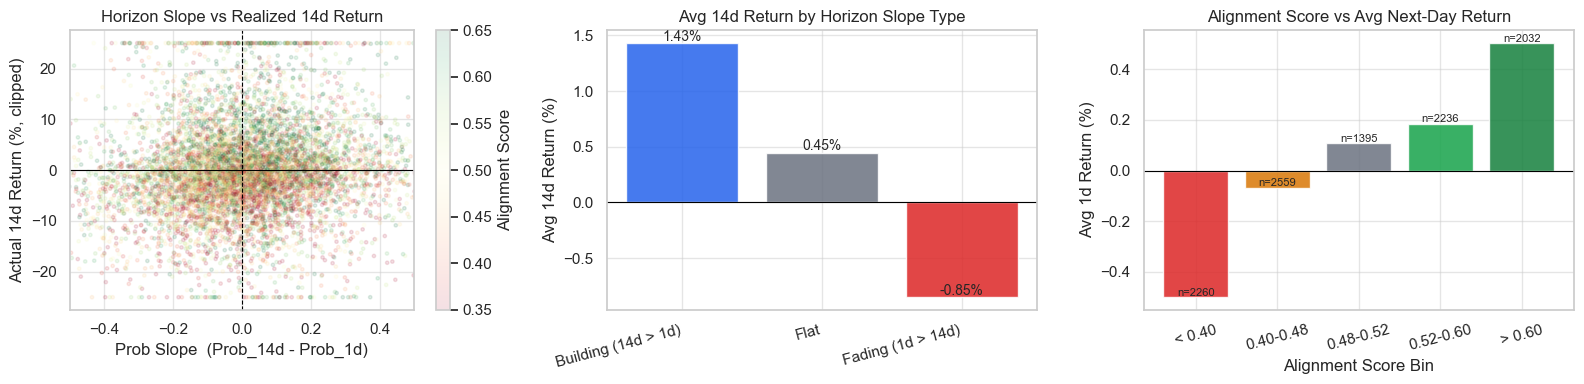


=== Slope Interpretation ===
  Building (14d > 1d)         1d avg: -0.229%  14d avg: +1.430%  n=3490
  Flat                        1d avg: -0.034%  14d avg: +0.448%  n=3618
  Fading (1d > 14d)           1d avg: +0.358%  14d avg: -0.850%  n=3374


In [25]:
if has_hist:
    fig, axes = plt.subplots(1, 3, figsize=(16, 4))

    # (1) Scatter: Prob_Slope vs 14d return
    sample = analysis_df.dropna(subset=['Return_14d']).sample(
        min(8000, analysis_df['Return_14d'].notna().sum()), random_state=42)
    sc = axes[0].scatter(sample['Prob_Slope'], sample['Return_14d'].clip(-0.25, 0.25) * 100,
                         alpha=0.12, s=6, c=sample['Alignment_Score'],
                         cmap='RdYlGn', vmin=0.35, vmax=0.65)
    axes[0].axhline(0, color='black', lw=0.8)
    axes[0].axvline(0, color='black', lw=0.8, ls='--')
    axes[0].set_xlabel('Prob Slope  (Prob_14d - Prob_1d)')
    axes[0].set_ylabel('Actual 14d Return (%, clipped)')
    axes[0].set_title('Horizon Slope vs Realized 14d Return')
    axes[0].set_xlim(-0.5, 0.5)
    plt.colorbar(sc, ax=axes[0], label='Alignment Score')

    # (2) Bar: slope type vs avg 14d return
    s_order = ['Building (14d > 1d)', 'Flat', 'Fading (1d > 14d)']
    s_cols  = ['#2563eb', '#6b7280', '#dc2626']
    s_plot  = slope_stats.reindex(s_order).dropna(subset=['AvgRet_14d%'])
    axes[1].bar(range(len(s_plot)), s_plot['AvgRet_14d%'], color=s_cols[:len(s_plot)], alpha=0.85)
    axes[1].axhline(0, color='black', lw=0.8)
    axes[1].set_xticks(range(len(s_plot)))
    axes[1].set_xticklabels(s_plot.index, rotation=15, ha='right')
    axes[1].set_title('Avg 14d Return by Horizon Slope Type')
    axes[1].set_ylabel('Avg 14d Return (%)')
    for i, v in enumerate(s_plot['AvgRet_14d%']):
        axes[1].text(i, v + 0.02, f'{v:.2f}%', ha='center', fontsize=10)

    # (3) Bar: alignment score buckets vs 1d avg return
    analysis_df['Align_Bin'] = pd.cut(analysis_df['Alignment_Score'],
                                       bins=[0, 0.40, 0.48, 0.52, 0.60, 1.0],
                                       labels=['< 0.40', '0.40-0.48', '0.48-0.52', '0.52-0.60', '> 0.60'])
    align_stats = (analysis_df.groupby('Align_Bin', observed=True)['Return_1d']
                   .agg(mean='mean', count='count').reset_index())
    align_stats['mean%'] = align_stats['mean'] * 100
    a_cols = ['#dc2626', '#d97706', '#6b7280', '#16a34a', '#15803d']
    axes[2].bar(range(len(align_stats)), align_stats['mean%'], color=a_cols[:len(align_stats)], alpha=0.85)
    axes[2].axhline(0, color='black', lw=0.8)
    axes[2].set_xticks(range(len(align_stats)))
    axes[2].set_xticklabels(align_stats['Align_Bin'].astype(str), rotation=15)
    axes[2].set_xlabel('Alignment Score Bin'); axes[2].set_ylabel('Avg 1d Return (%)')
    axes[2].set_title('Alignment Score vs Avg Next-Day Return')
    for i, row in align_stats.iterrows():
        axes[2].text(i, row['mean%'] + 0.005, f'n={int(row["count"])}', ha='center', fontsize=8)

    plt.tight_layout(); plt.show()

    print('\n=== Slope Interpretation ===')
    for stype in s_order:
        if stype in slope_stats.index:
            r = slope_stats.loc[stype]
            print(f'  {stype:<26}  1d avg: {r["AvgRet_1d%"]:+.3f}%  14d avg: {r["AvgRet_14d%"]:+.3f}%  n={int(r["Count"])}')

---
## 11. Multi-Strategy Backtest Comparison

We implement four trading strategies that use the horizon signals differently
and compare their performance head-to-head on the same stocks and time period.

### Strategy Definitions

| Strategy | Entry Condition | Exit Condition | Philosophy |
|----------|----------------|----------------|------------|
| **Baseline** | 1d Prob > 0.70 | 1d Prob < 0.35 | Original strategy: act purely on next-day signal |
| **Consensus** | ALL 5 horizons > 0.58 | ANY horizon < 0.40 | Maximum conviction — only enter when all time-scales agree |
| **Dip Buy** | 14d Prob > 0.62 AND 1d Prob < 0.52 | 14d Prob < 0.40 | Buy near-term weakness within a medium-term uptrend |
| **Alignment** | Avg(all 5 probs) > 0.60 | Avg < 0.45 | Weighted consensus: enter when the overall "model vote" is bullish |

### Expected Behavior

- **Baseline** will have the most trades (1d alone fires most often), moderate win rate.
- **Consensus** will have the fewest trades but highest precision — every entry has multi-timeframe support.
  The downside is many missed opportunities when some horizons disagree.
- **Dip Buy** targets a different entry timing — entering after a 1d pullback rather than at
  peak momentum. Expect lower 1d hit rate but potentially better 14d outcome.
- **Alignment** is the balanced middle ground — doesn't require full consensus but filters out
  single-horizon noise.

This comparison uses the `daily_predictions` table so all five horizon probs are
available simultaneously at each bar.

In [26]:
def run_dp_strategy(stock_id, dp_df, prices_df, strategy='baseline'):
    '''
    Simulate a trading strategy using pre-computed daily_predictions as signal source.
    Returns (equity_df, trades_df) where equity_df has columns Strategy and Benchmark.
    '''
    spd = dp_df[dp_df['Stock_ID'] == stock_id].sort_values('Date').copy()
    spr = prices_df[prices_df['Stock_ID'] == stock_id].sort_values('Date')

    df = spd.merge(spr[['Date', 'Close']], on='Date', how='inner').dropna(subset=['Close'])
    if BT2.EVAL_START_DATE:
        df = df[df['Date'] > pd.Timestamp(BT2.EVAL_START_DATE)]
    if len(df) < 30:
        return None, None

    avail_prob_cols = [c for c in ['Prob_1d', 'Prob_2d', 'Prob_3d', 'Prob_7d', 'Prob_14d']
                       if c in df.columns]

    closes     = df['Close'].values.astype(float)
    dates      = pd.to_datetime(df['Date'].values)
    bm_shares  = BT2.INITIAL_CAPITAL / (closes[0] * (1 + BT2.FEE + BT2.SLIPPAGE))

    cash = float(BT2.INITIAL_CAPITAL); shares = 0.0
    entry_price = None; entry_date = None
    equity_curve = []; bm_curve = []; trade_log = []

    for i in range(len(df)):
        price = closes[i]
        date  = dates[i]
        row   = df.iloc[i]
        p1    = float(row.get('Prob_1d',  0.5))
        p14   = float(row.get('Prob_14d', 0.5))
        p_all = [float(row.get(c, 0.5)) for c in avail_prob_cols]
        p_mean = float(np.mean(p_all))

        buy_signal = sell_signal = False

        if strategy == 'baseline':
            buy_signal  = p1 > 0.70
            sell_signal = p1 < 0.35

        elif strategy == 'consensus':
            buy_signal  = all(float(row.get(c, 0)) > 0.58 for c in avail_prob_cols)
            sell_signal = any(float(row.get(c, 1)) < 0.40 for c in avail_prob_cols)

        elif strategy == 'dip_buy':
            # Enter when longer-term is bullish but near-term is pulling back (buy the dip)
            buy_signal  = (p14 > 0.62) and (p1 < 0.52)
            sell_signal = (p14 < 0.40) or (p1 < 0.30)

        elif strategy == 'alignment':
            buy_signal  = p_mean > 0.60
            sell_signal = p_mean < 0.45

        if shares == 0 and buy_signal:
            shares = cash / (price * (1 + BT2.FEE + BT2.SLIPPAGE))
            cash = 0.0; entry_price = price; entry_date = date

        elif shares > 0 and sell_signal:
            cash = shares * price * (1 - BT2.FEE - BT2.TAX - BT2.SLIPPAGE)
            ret  = (price * (1 - BT2.FEE - BT2.TAX - BT2.SLIPPAGE)) / \
                   (entry_price * (1 + BT2.FEE + BT2.SLIPPAGE)) - 1
            trade_log.append({'entry_date': entry_date, 'exit_date': date,
                               'entry_price': entry_price, 'exit_price': price,
                               'return_pct': ret, 'holding_days': (date - entry_date).days})
            shares = 0.0; entry_price = None; entry_date = None

        equity_curve.append(shares * price if shares > 0 else cash)
        bm_curve.append(bm_shares * price)

    if shares > 0:
        equity_curve[-1] = shares * closes[-1] * (1 - BT2.FEE - BT2.TAX - BT2.SLIPPAGE)
    bm_curve[-1] *= (1 - BT2.FEE - BT2.TAX - BT2.SLIPPAGE)

    eq_df = pd.DataFrame({'Strategy': equity_curve, 'Benchmark': bm_curve},
                          index=pd.DatetimeIndex(dates))
    tr_df = pd.DataFrame(trade_log) if trade_log else pd.DataFrame(
        columns=['entry_date', 'exit_date', 'entry_price', 'exit_price', 'return_pct', 'holding_days'])
    return eq_df, tr_df

In [27]:
STRATEGIES = {
    'baseline':  '1d Prob > 0.70',
    'consensus': 'All Horizons > 0.58',
    'dip_buy':   '14d>0.62 AND 1d<0.52',
    'alignment': 'Avg Prob > 0.60',
}

if has_dp:
    dp_stocks    = set(dp['Stock_ID'].unique())
    eval_stocks  = [s for s in test_stocks if s in dp_stocks]
    if not eval_stocks:
        eval_stocks = list(dp_stocks)[:5]
        print(f'Test stocks not in daily_predictions; using first 5 available: {eval_stocks}')
    else:
        print(f'Evaluating on: {eval_stocks}')

    multi_results = {s_key: {} for s_key in STRATEGIES}

    for stock_id in eval_stocks:
        for s_key in STRATEGIES:
            eq_df, tr_df = run_dp_strategy(stock_id, dp, prices_raw, s_key)
            if eq_df is None:
                continue
            m  = BT2.compute_metrics(eq_df['Strategy'],  tr_df,          s_key, BT2.INITIAL_CAPITAL)
            bm = BT2.compute_metrics(eq_df['Benchmark'], pd.DataFrame(), 'B&H', BT2.INITIAL_CAPITAL)
            multi_results[s_key][stock_id] = {'metrics': m, 'bm': bm, 'equity_df': eq_df, 'trades': tr_df}

    print('Done.')
else:
    multi_results = {}
    print('Skipped — daily_predictions not available.')

Evaluating on: ['6005', '2399', '6241', '2726', '9929', '2948', '3041', '4907', '6419', '6958']
Done.


In [28]:
def _pct(s):
    try: return float(str(s).rstrip('%').replace('+', ''))
    except: return 0.0

if multi_results and any(multi_results[k] for k in multi_results):
    # ── Summary comparison table ──────────────────────────────────────────────
    rows = []
    for s_key, label in STRATEGIES.items():
        res_list = list(multi_results[s_key].values())
        if not res_list: continue
        rows.append({
            'Strategy':      label,
            'Avg Return %':  round(np.mean([_pct(r['metrics'].get('Total Return', '0%')) for r in res_list]), 2),
            'Avg Sharpe':    round(np.mean([float(r['metrics'].get('Sharpe Ratio', 0))   for r in res_list]), 2),
            'Avg MaxDD %':   round(np.mean([_pct(r['metrics'].get('Max Drawdown', '0%')) for r in res_list]), 2),
            'Avg WinRate %': round(np.mean([_pct(r['metrics'].get('Win Rate', '0%'))     for r in res_list]), 1),
            'Avg Trades':    round(np.mean([int(r['metrics'].get('Num Trades', 0))        for r in res_list]), 1),
        })
    bh_row = {'Strategy': 'Buy & Hold'}
    bh_rets = []
    for s_key in multi_results:
        for res in multi_results[s_key].values():
            bh_rets.append(_pct(res['bm'].get('Total Return', '0%')))
    if bh_rets:
        bh_row['Avg Return %'] = round(np.mean(bh_rets), 2)
        bh_row['Avg Sharpe']   = round(np.mean([float(res['bm'].get('Sharpe Ratio', 0))
                                                 for r in multi_results.values() for res in r.values()]), 2)
        rows.append(bh_row)

    comp_df = pd.DataFrame(rows).set_index('Strategy')
    print('=== Strategy Comparison (averaged across test stocks) ===')
    display(comp_df)

    # ── Equity curves for first available stock ───────────────────────────────
    first_stock = next((s for s in eval_stocks
                        if any(s in multi_results[k] for k in STRATEGIES)), None)

    if first_stock:
        fig = go.Figure()
        clr = {'baseline': '#7c3aed', 'consensus': '#16a34a', 'dip_buy': '#2563eb', 'alignment': '#d97706'}
        bm_added = False
        for s_key, label in STRATEGIES.items():
            if first_stock not in multi_results[s_key]: continue
            res = multi_results[s_key][first_stock]
            eq  = res['equity_df']['Strategy']
            fig.add_trace(go.Scatter(x=eq.index, y=eq / eq.iloc[0] * 100,
                                     name=label, line=dict(color=clr.get(s_key, '#999'), width=2)))
            if not bm_added:
                bm = res['equity_df']['Benchmark']
                fig.add_trace(go.Scatter(x=bm.index, y=bm / bm.iloc[0] * 100,
                                         name='Buy & Hold',
                                         line=dict(color='#6b7280', width=1.5, dash='dash')))
                bm_added = True

        fig.update_layout(
            title=f'Multi-Strategy Equity Comparison  |  {first_stock}  (normalized to 100)',
            height=500, hovermode='x unified', yaxis_title='Normalized Value',
            legend=dict(orientation='h', yanchor='bottom', y=1.02, xanchor='right', x=1))
        fig.show()

        # ── Per-strategy trade summary for this stock ─────────────────────────
        print(f'\n=== Trade Summary for {first_stock} ===')
        print(f'{"Strategy":<26}  {"Trades":>7}  {"WinRate":>8}  {"AvgRet":>8}  {"AvgHold":>8}')
        print('  ' + '-' * 62)
        for s_key, label in STRATEGIES.items():
            if first_stock not in multi_results[s_key]: continue
            tr = multi_results[s_key][first_stock]['trades']
            if tr.empty:
                print(f'  {label:<26}  No trades')
                continue
            wr  = (tr['return_pct'] > 0).mean()
            ar  = tr['return_pct'].mean()
            ah  = tr['holding_days'].mean()
            print(f'  {label:<26}  {len(tr):>7}  {wr:>8.2%}  {ar:>+8.3%}  {ah:>7.1f}d')

---
## 12. Market Scan — Today's Top Picks

Scan the full TWSE universe (~1,900+ stocks) with the 1d model.

**Threshold selection**: we use the optimal threshold from Section 3 (max F1 on test set)
rather than the backtest's 0.70 threshold. The classification threshold and the trading
threshold serve different purposes:
- **Classification threshold** (max-F1): best balance of precision and recall for *identifying*
  candidates from a full universe scan.
- **Trading threshold** (0.70): higher bar used when *executing* a trade to maximize precision.

**Runtime**: ~3-5 minutes for the full scan.

**Multi-horizon consensus check**: after the scan, we cross-reference with the
`daily_predictions` table to flag stocks where ALL five horizon models agree (all > 55%).
These are the highest-confidence picks.

Optimal threshold from 1d model: 0.3826

════════════════════════════════════════════════════════════
SECTION 5 — Market Scan (1d model)
════════════════════════════════════════════════════════════
  Scanning 1966 stocks  (threshold=0.3826) ...
  ... 200/1966
  ... 400/1966
  ... 600/1966
  ... 800/1966
  ... 1000/1966
  ... 1200/1966
  ... 1400/1966
  ... 1600/1966
  ... 1800/1966

  Stocks above threshold: 1847

  Top 20:
Stock_ID       Date     Close    Volume  Prob_Up
    6806 2026-05-12   19.2000    767190   0.7630
    5601 2026-05-19   35.1000     17000   0.7218
    6887 2026-05-26   31.9000     81807   0.7092
    6230 2026-05-27  137.0000    139926   0.6947
    3426 2026-05-26   47.7500      6000   0.6810
    2303 2026-05-27  143.5000 278317004   0.6808
    6510 2026-05-27 3195.0000   1318135   0.6803
    3665 2026-05-27 2115.0000   2207901   0.6797
    6658 2026-05-26  233.0000   2221421   0.6716
    8291 2026-05-06   29.3000    154780   0.6696
    6936 2026-05-26   33.0000    

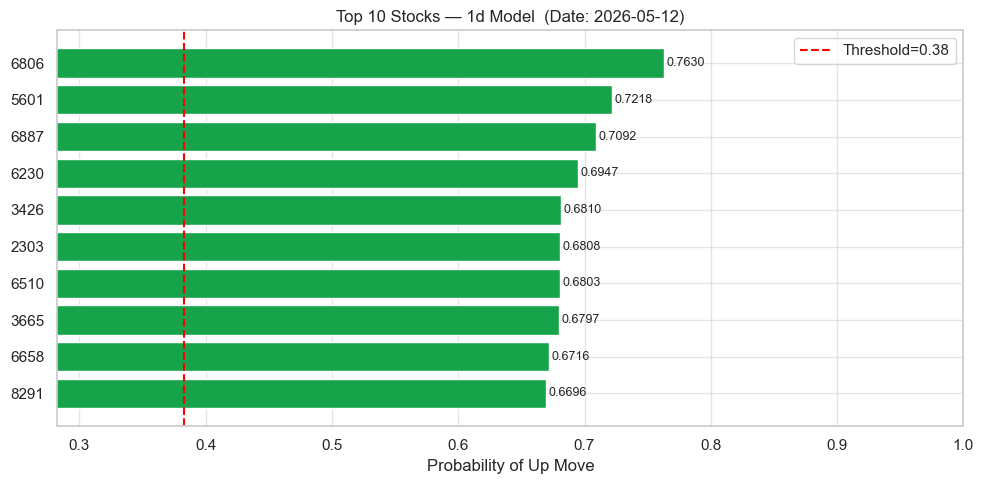

In [29]:
RUN_MARKET_SCAN = True

if RUN_MARKET_SCAN:
    if horizon_results and 1 in horizon_results:
        scan_thr = horizon_results[1]['threshold']
        print(f'Optimal threshold from 1d model: {scan_thr:.4f}')
    else:
        scan_thr = 0.55
        print(f'Using fallback threshold: {scan_thr}')
    scan_results = PR2.section5_market_scan(target_days=1, threshold=scan_thr)
else:
    print('Market scan skipped. Set RUN_MARKET_SCAN = True to run.')

---
## Summary & Key Takeaways

### Decision Framework (using all horizon signals)

```
GIVEN: Prob_1d, Prob_2d, Prob_3d, Prob_7d, Prob_14d for stock X

Step 1 — Compute derived signals:
  Alignment_Score = mean(all 5 probs)
  Prob_Slope      = Prob_14d - Prob_1d

Step 2 — Classify:
  if Alignment_Score > 0.60  AND  Prob_1d > 0.70  ->  STRONG BUY   (Quadrant A)
  if Alignment_Score > 0.60  AND  Prob_1d < 0.50  ->  DIP BUY      (Quadrant B)
  if Prob_Slope < -0.10      AND  Prob_1d > 0.60  ->  FADE, skip   (Quadrant C)
  if Alignment_Score < 0.45                        ->  AVOID        (Quadrant D)
  else                                             ->  NEUTRAL, wait

Step 3 — Size position:
  Quadrant A: normal size (e.g., 5-10% of portfolio)
  Quadrant B: smaller size (e.g., 3-5%) — we're catching a falling knife within an uptrend
  Quadrant C: no entry

Step 4 — Set exit:
  Exit when Prob_14d drops below 0.40 OR Prob_1d drops below 0.30
```

### What the Backtest Taught Us

1. **Cost discipline is critical**: at 0.685% round-trip cost, you need at least 5-6 winning
   trades per year just to break even on costs. Low-frequency, high-conviction entries win.

2. **Longer horizons = more patience required**: the 7d and 14d models have higher classification
   AUC but require you to hold through noise. The threshold sweep shows that a wider entry
   dead-zone (high buy, low sell) dramatically reduces overtrading.

3. **Dip buying works when calibration is good**: if the 14d model is well-calibrated
   (Section 6 confirms this), entering on 1d weakness is a *feature*, not a bug.
   You get a better price for the same expected 14d outcome.

4. **Consensus strategy has fewer but higher-quality trades**: if your priority is capital
   preservation, require all horizons to agree before entering. Fewer trades means less
   total cost drag and fewer forced decisions under uncertainty.

### Limitations to Keep in Mind

- All backtests assume **closing-price execution**. Live trading requires submitting orders
  before the close (e.g., a 2:30pm pre-close order in TWSE).
- **No portfolio-level risk management**: each stock is analyzed independently. In a real
  portfolio, concentration limits and correlation-based position sizing are needed.
- **Regime overlap**: the model was trained on the same historical regimes it is being tested on.
  Period-specific events (COVID, rate hike cycle) that appear in both training and test data
  can make backtests look better than live trading will.

In [30]:
# Multi-horizon consensus: stocks where ALL horizons > 0.55
try:
    conn = sqlite3.connect(DB_PATH)
    dp_latest_all = pd.read_sql('SELECT * FROM daily_predictions ORDER BY Date DESC', conn)
    conn.close()
    if not dp_latest_all.empty:
        latest_date  = dp_latest_all['Date'].max()
        dp_ld        = dp_latest_all[dp_latest_all['Date'] == latest_date].copy()
        prob_cols    = [c for c in dp_ld.columns if c.startswith('Prob_')]
        consensus    = dp_ld.copy()
        for col in prob_cols:
            consensus = consensus[consensus[col] > 0.55]
        consensus = consensus.sort_values('Prob_1d', ascending=False)
        print(f'Latest prediction date         : {latest_date}')
        print(f'Total stocks with predictions  : {len(dp_ld)}')
        print(f'All-horizon consensus (> 0.55) : {len(consensus)} stocks')
        if not consensus.empty:
            print('\nTop picks (all 5 horizons bullish):')
            display(consensus[['Stock_ID', 'Close_Price'] + prob_cols].head(20))
    else:
        print('daily_predictions table is empty.')
except Exception as e:
    print(f'Could not load daily_predictions: {e}')

Latest prediction date         : 2026-05-28
Total stocks with predictions  : 1934
All-horizon consensus (> 0.55) : 46 stocks

Top picks (all 5 horizons bullish):


,Stock_ID,Close_Price,Prob_1d,Prob_2d,Prob_3d,Prob_7d,Prob_14d
1333,3042,217.500000,0.651137,0.732115,0.636236,0.774845,0.805731
350,6831,832.000000,0.623841,0.562795,0.635870,0.840344,0.641448
591,6230,137.500000,0.622741,0.618032,0.674010,0.640501,0.550363
1357,3016,138.500000,0.617029,0.745427,0.621186,0.791246,0.791181
1164,3508,20.700001,0.613635,0.578890,0.646708,0.593000,0.678252
585,6239,374.500000,0.613158,0.695979,0.569224,0.753621,0.712272
667,6141,43.200001,0.610191,0.765477,0.698533,0.616864,0.720077
431,6654,140.000000,0.606380,0.740489,0.682129,0.664490,0.574099
394,6727,609.000000,0.606294,0.618508,0.589449,0.801756,0.754898
203,8028,338.500000,0.605672,0.694256,0.609191,0.674087,0.758804
